### Code funzionante

In [311]:
bits = 16

a = 3230
b = 60

lut = [(1 << (bits * 2)) // ((1 << bits - 1) | (i << bits)) for i in range(bits * 2)]
#or
lut = [2**(bits + 1) // (2*i + 1) for i in range(bits * 2)]

s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> round(bits / 2)) & (bits - 1)
#print(idx)
# STO USANDO SOLO INDEX DA 1 a BITS, MA LUT HA BITS * 2


x = lut[idx] 
print("First guess", a * x >> (bits * 2 - s))

for _ in range(6):
    x = (x * ((2 << bits * 2) - b_norm * x)) >> bits * 2

result = (a * x) >> (bits * 2 - s)

print(result)
print(a // b)  

First guess 100
53
53


In [184]:
a * lut[idx] >> 32 - s

12

In [138]:
2**(bits + 1) / math.sqrt(3)

75674.45448322264

In [89]:
len(lut)

32

In [51]:
2**16

65536

In [13]:
2 << 5

64

In [14]:
2**5

32

In [10]:
b.bit_length()

12

### Todo: map the LUT as a polynomial

In [90]:
def get_bit(n, i):
    return (n >> i) & 1

In [91]:
import numpy as np
import math

def polylut(bit = 0):
    N = bits * 2
    seq = np.array([get_bit(lut[i], bit) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

f = polylut(0)

# Verifica sui punti di interpolazione
print("Verifica interpolazione:")
for x in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    val = f(x)
    expected = polylut(0)(x)
    print(f"  x={x:3d}: f(x)={val:.6f}, f(x)={expected:.6f}, err={abs(val-expected):.2e}")

Verifica interpolazione:
  x=  0: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  1: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  2: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  3: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  4: f(x)=1.000000, f(x)=1.000000, err=0.00e+00
  x=  5: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  6: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  7: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  8: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  9: f(x)=1.000000, f(x)=1.000000, err=0.00e+00
  x= 10: f(x)=1.000000, f(x)=1.000000, err=0.00e+00


In [92]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [93]:
polyluts = []

for bit in range(bits + 2):
    f = polylut(bit)
    
    c = Chebyshev(0, bits * 2, 451, f)
    
    polyluts.append(c)

4.057537639212683e-11

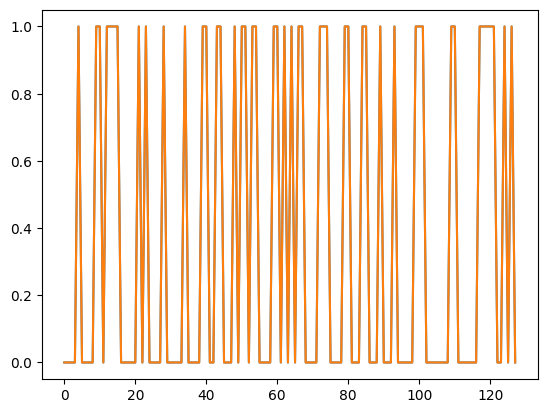

In [94]:
# example
index = 0

x = np.arange(0, bits * 2, 1)

y = np.vectorize(polyluts[index].eval)(x)

plt.plot(x, y)

real = []

for i in range(len(lut)):
    real.append(get_bit(lut[i], index))
    
plt.plot(real)

max(abs(real - y))

### Step 1: doing the same as above but with poly

In [95]:
a = 8139241343909139012
b = 2

lut = [(1 << bits * 2) // ((1 << bits - 1) | (i << round(bits / 2))) for i in range(bits * 2)]

s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> round(bits / 2)) & (bits - 1)

idx

0

In [96]:
binx = []

for i in range(bits * 2):
    if i >= len(polyluts):
        binx.append(0)
    else:
        binx.append(polyluts[i].eval(idx))

In [97]:
polydec = ([round(x) for x in list(binx)][::-1])

In [98]:
n = int("".join(map(str, polydec)), 2)

In [99]:
x = n

for _ in range(7):
    term = b_norm * x #Mult
    term = 2**(bits * 2 + 1) - term  #Implementato come !term + 1, dove i bit più alti di 33 sono a 0
    
    x = x * term #Mult normale
    x = x >> bits * 2 #Shift gratis

result = (a * x) >> (bits * 2 - s)
result

4069620671954569506

In [100]:
a // b

4069620671954569506

In [299]:
bits = 16

b = 310

lut = [(1 << (bits * 2)) // ((1 << bits - 1) | (i << bits)) for i in range(bits * 2)]
#or
lut = [2**(bits + 1) // math.isqrt(2*i + 1) for i in range(bits * 2)]

s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> round(bits / 2)) & (bits * 2 - 1)

x = lut[idx]

print("idx", idx)

#for _ in range(6):
#    x = (x * ((2 << bits * 2) - b_norm * x)) >> bits * 2

result = (b * x) >> bits * 2 - s

print(result)
print(math.isqrt(b))

idx 27
0
17


In [293]:
s

11

In [291]:
bin(b)

'0b11111'

In [292]:
bin(b_norm)

'0b1111100000000000'

In [294]:
b_norm >> s

31

In [239]:
lut

[131072,
 131072,
 65536,
 65536,
 43690,
 43690,
 43690,
 43690,
 32768,
 32768,
 32768,
 32768,
 26214,
 26214,
 26214,
 26214,
 26214,
 26214,
 21845,
 21845,
 21845,
 21845,
 21845,
 21845,
 18724,
 18724,
 18724,
 18724,
 18724,
 18724,
 18724,
 18724]

In [176]:
b.bit_length()

14

In [189]:
lut_rsqrt[idx]

131072

In [190]:
math.isqrt(b)

17

In [126]:
lut

[131072,
 43690,
 26214,
 18724,
 14563,
 11915,
 10082,
 8738,
 7710,
 6898,
 6241,
 5698,
 5242,
 4854,
 4519,
 4228,
 3971,
 3744,
 3542,
 3360,
 3196,
 3048,
 2912,
 2788,
 2674,
 2570,
 2473,
 2383,
 2299,
 2221,
 2148,
 2080]

In [127]:
LUT_BITS = 5
LUT_SIZE = 1 << LUT_BITS

lut_rsqrt = [
    int((1 << bits) / math.sqrt((LUT_SIZE + i) / LUT_SIZE))
    for i in range(LUT_SIZE)
]

lut_rsqrt

[65536,
 64535,
 63579,
 62664,
 61787,
 60947,
 60139,
 59363,
 58617,
 57897,
 57204,
 56535,
 55889,
 55264,
 54660,
 54076,
 53509,
 52961,
 52428,
 51912,
 51410,
 50923,
 50449,
 49988,
 49540,
 49104,
 48678,
 48264,
 47860,
 47466,
 47082,
 46707]

In [35]:
import math
math.isqrt(a)

61